Assignment 1
Face Recognition Using SVM and PCA

A) Imports and preview an image

Using Face folder at:
C:\Users\arman\OneDrive\Desktop\Face
Number of samples in label.csv: 400
Columns in label.csv: ['Label']


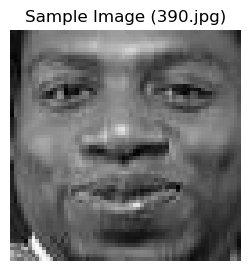

Image shape: (64, 64)


In [25]:
#Setup and imports
%matplotlib inline

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path
face_dir = Path.home() / "OneDrive" / "Desktop" / "Face"

print("Using Face folder at:")
print(face_dir)

# Checking if folder exists
if not face_dir.exists():
    raise FileNotFoundError(
        "Face folder not found."
    )

# Checking label.csv exists
labels_path = face_dir / "label.csv"
if not labels_path.exists():
    raise FileNotFoundError("label.csv not found inside Face folder.")

# Loading labels
labels_df = pd.read_csv(labels_path)

print("Number of samples in label.csv:", len(labels_df))
print("Columns in label.csv:", list(labels_df.columns))

# Preview one image (example: 390.jpg)
sample_image_path = face_dir / "390.jpg"

if not sample_image_path.exists():
    raise FileNotFoundError("0.jpg not found inside Face folder.")

img = mpimg.imread(sample_image_path)

plt.figure(figsize=(3,3))
plt.imshow(img, cmap=plt.cm.gray)
plt.title("Sample Image (390.jpg)")
plt.axis("off")
plt.show()

print("Image shape:", img.shape)

B) Building feature matrix X and label vector y
   Each image is 64x64 = 4096 pixels, flattened into 4096 features

In [26]:
import numpy as np

# Making sure label.csv has a column named "Label"
if "Label" not in labels_df.columns:
    raise ValueError("label.csv must contain a column named 'Label'.")

# Label vector (person IDs)
y = labels_df["Label"].to_numpy()

# Collect all .jpg files and sort them numerically: 0.jpg, 1.jpg, ..., ect
image_paths = sorted(face_dir.glob("*.jpg"), key=lambda p: int(p.stem))

# Confirm dataset size matches labels
if len(image_paths) != len(y):
    raise ValueError(f"Found {len(image_paths)} images but {len(y)} labels in label.csv.")

# Build the feature matrix
X_list = []

for img_path in image_paths:
    img = mpimg.imread(str(img_path))

    # If the image loads as RGB (3 channels), convert to grayscale by taking one channel
    if img.ndim == 3:
        img = img[:, :, 0]

    # Ensure image is 64x64 as expected
    if img.shape != (64, 64):
        raise ValueError(f"Unexpected image shape {img.shape} in {img_path.name}, expected (64, 64).")

    # Flatten 64x64 -> 4096 and store as one row
    X_list.append(img.reshape(-1))

# Stack rows to form the feature matrix (400, 4096)
X = np.vstack(X_list)

print("X shape:", X.shape)  # expected (400, 4096)
print("y shape:", y.shape)  # expected (400,)
print("Unique people:", len(np.unique(y)))  # expected 40

X shape: (400, 4096)
y shape: (400,)
Unique people: 40


C) Normalization
   Normalizing each column of X using preprocessing.scale
   This makes each feature column have mean 0 and std 1

In [27]:
from sklearn import preprocessing

X_normalized = preprocessing.scale(X)

print("X_normalized shape:", X_normalized.shape)

# first 5 features check
print("Mean first 5 features:", np.mean(X_normalized, axis=0)[:5])
print("Std first 5 features:", np.std(X_normalized, axis=0)[:5])

X_normalized shape: (400, 4096)
Mean first 5 features: [-6.67521594e-17 -7.96585020e-17  5.38458167e-17  1.62092562e-16
 -4.88498131e-17]
Std first 5 features: [1. 1. 1. 1. 1.]


D) Train test split
   test_size=0.25, random_state=5

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.25, random_state=5)

print("X_train shape:", X_train.shape)  # expected (300, 4096)
print("X_test shape:", X_test.shape)    # expected (100, 4096)

X_train shape: (300, 4096)
X_test shape: (100, 4096)


E) PCA dimensionality reduction from 4096 to 50
   Fit PCA on training data only, then transform train and test

In [29]:
from sklearn.decomposition import PCA

k = 50  # number of principal components

my_pca = PCA(n_components=k)

# Fiting PCA on training set only, then transform train and test
X_Train_new = my_pca.fit_transform(X_train)
X_Test_new = my_pca.transform(X_test)

print("X_Train_new shape:", X_Train_new.shape)  # expected (300, 50)
print("X_Test_new shape:", X_Test_new.shape)    # expected (100, 50)


X_Train_new shape: (300, 50)
X_Test_new shape: (100, 50)


F) Non-linear SVM with RBF kernel
   Use: SVC(C=1, kernel='rbf', gamma=0.0005, random_state=1)
   Train on training set, test on testing set, report accuracy
   Also report confusion matrix using confusion_matrix(y_test, y_predict)

In [30]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

svm_model = SVC(C=1, kernel='rbf', gamma=0.0005, random_state=1)

# Training SVM on PCA-reduced training data
svm_model.fit(X_Train_new, y_train)

# Predicting on PCA-reduced testing data
y_predict = svm_model.predict(X_Test_new)

# Accuracy
acc = accuracy_score(y_test, y_predict)
print("Test accuracy:", acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_predict)
print("Confusion matrix shape:", cm.shape)
print(cm)

Test accuracy: 0.91
Confusion matrix shape: (37, 37)
[[3 0 0 ... 0 0 0]
 [0 3 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 4 0]
 [0 0 0 ... 0 0 1]]


G) GridSearchCV to find best C with scoring='accuracy'
   Searching C in: [0.1, 1, 10, 100, 1e3, 5e3, 1e4, 5e4, 1e5]
   Not useing X_train and X_test anymore.
   PCA on the ENTIRE dataset after normalization:
   X_normalized_pca = my_pca.fit_transform(X_normalized), then use GridSearchCV with 10-fold cross validation to find best C.

In [31]:
from sklearn.model_selection import GridSearchCV

# PCA on the full normalized dataset (as instructed for part g)
k = 50
my_pca = PCA(n_components=k)

X_normalized_pca = my_pca.fit_transform(X_normalized)
print("X_normalized_pca shape:", X_normalized_pca.shape)  # expected (400, 50)

# Grid of C values to test
C_list = [0.1, 1, 10, 100, 1e3, 5e3, 1e4, 5e4, 1e5]
param_grid = {"C": C_list}

# SVM model for grid search (kernel and gamma fixed, only C changes)
svm_for_grid = SVC(kernel='rbf', gamma=0.0005, random_state=1)

# 10-fold cross validation, scoring by accuracy
grid = GridSearchCV(
    estimator=svm_for_grid,
    param_grid=param_grid,
    scoring='accuracy',
    cv=10,
    n_jobs=-1
)

grid.fit(X_normalized_pca, y)

print("Best C:", grid.best_params_["C"])
print("Best 10-fold CV accuracy:", grid.best_score_)


X_normalized_pca shape: (400, 50)
Best C: 10
Best 10-fold CV accuracy: 0.9649999999999999
